In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, Input, Add, Activation, SeparableConv2D

def build_model(input_shape=(48, 48, 1), num_classes=7):
    """Kiến trúc CNN cải tiến sử dụng các khối Separable và Residual nhẹ"""
    input_img = Input(shape=input_shape)

    # Module 1
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(input_img)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # Module 2 (Residual Block đơn giản)
    shortcut = Conv2D(128, (1, 1), strides=(2, 2), padding='same')(x)
    x = SeparableConv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = SeparableConv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Add()([x, shortcut])
    x = Dropout(0.25)(x)

    # Module 3
    x = SeparableConv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_img, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

### 1. Tải xuống bộ dữ liệu FER2013

Chúng ta sẽ sử dụng thư viện `opendatasets` để tải bộ dữ liệu FER2013 từ Kaggle. Bạn sẽ cần nhập tên người dùng và khóa API Kaggle của mình. Nếu chưa có, bạn có thể tạo khóa API trên trang hồ sơ Kaggle của mình.

In [13]:
# Removed opendatasets method as kagglehub is now used.
# Original code:
# !pip install opendatasets -q
# import opendatasets as od
# import os
# dataset_url = 'https://www.kaggle.com/datasets/msambare/fer2013'
# try:
#     od.download(dataset_url)
#     print("✅ Đã tải xuống bộ dữ liệu FER2013!")
# except Exception as e:
#     print(f"❌ Lỗi khi tải xuống bộ dữ liệu: {e}")
#     print("Vui lòng đảm bảo bạn đã cấu hình thông tin đăng nhập Kaggle chính xác.")

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


### 2. Tải và tiền xử lý dữ liệu

Sau khi tải xuống, chúng ta sẽ tải dữ liệu từ tệp `fer2013.csv` vào DataFrame của Pandas, tiền xử lý các pixel hình ảnh và chuẩn bị dữ liệu cho việc huấn luyện mô hình.

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Đường dẫn thực tế từ biến 'path' do kagglehub trả về
# Thông thường cấu trúc sẽ là: path/train và path/test
base_path = path
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

# Image dimensions
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 64
NUM_CLASSES = 7

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load data
try:
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='categorical'
    )

    validation_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode='grayscale',
        class_mode='categorical'
    )

    print(f"✅ Tải dữ liệu thành công từ: {base_path}")
    print(f"Tìm thấy {train_generator.samples} ảnh tập train và {validation_generator.samples} ảnh tập test.")
    class_labels = list(train_generator.class_indices.keys())
    print("Nhãn cảm xúc:", train_generator.class_indices)
except Exception as e:
    print(f"❌ Vẫn còn lỗi đường dẫn: {e}")
    print(f"Nội dung thư mục hiện tại ({base_path}):", os.listdir(base_path) if os.path.exists(base_path) else 'Thư mục không tồn tại')


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
✅ Tải dữ liệu thành công từ: /kaggle/input/fer2013
Tìm thấy 28709 ảnh tập train và 7178 ảnh tập test.
Nhãn cảm xúc: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


### 3. Huấn luyện mô hình và lưu lại

Bây giờ chúng ta sẽ huấn luyện mô hình đã được định nghĩa trong cell trước (`build_model`) sử dụng dữ liệu đã tiền xử lý. Sau khi huấn luyện, mô hình sẽ được lưu vào tệp `emotion_model.h5`.

### Khởi tạo `ImageDataGenerator` và các trình tạo dữ liệu (Generators)

Chúng ta sẽ sử dụng `ImageDataGenerator` từ TensorFlow Keras để tiền xử lý và tăng cường dữ liệu hình ảnh, tạo ra các trình tạo dữ liệu (`train_generator` và `validation_generator`) để cung cấp dữ liệu theo lô cho quá trình huấn luyện mô hình.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Define paths for training and testing data based on kagglehub download
# Corrected base_path to reflect actual kagglehub download location, often there's an extra subdirectory
base_path = '/kaggle/input/fer2013'
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

# Image dimensions
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 64
NUM_CLASSES = 7

# Data Augmentation and Preprocessing for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Preprocessing for Test Data (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical'
)

print(f"✅ Tải dữ liệu từ thư mục {train_dir} và {test_dir} thành công!")
print(f"Tìm thấy {train_generator.samples} hình ảnh thuộc {train_generator.num_classes} lớp trong tập huấn luyện.")
print(f"Tìm thấy {validation_generator.samples} hình ảnh thuộc {validation_generator.num_classes} lớp trong tập kiểm tra.")

print("Nhãn cảm xúc:", train_generator.class_indices)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
✅ Tải dữ liệu từ thư mục /kaggle/input/fer2013/train và /kaggle/input/fer2013/test thành công!
Tìm thấy 28709 hình ảnh thuộc 7 lớp trong tập huấn luyện.
Tìm thấy 7178 hình ảnh thuộc 7 lớp trong tập kiểm tra.
Nhãn cảm xúc: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


### Định nghĩa lại hàm `build_model` (đảm bảo hàm được khai báo trước khi sử dụng)

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, Input

def build_model(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential([
        Input(shape=input_shape), # Explicitly define Input layer
        # Khối 1
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Khối 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Khối 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [18]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Xây dựng mô hình
model = build_model(input_shape=(48, 48, 1), num_classes=7)
model.summary()

# Huấn luyện mô hình
epochs = 15 # Bạn có thể điều chỉnh số epoch
# batch_size = 64 # This batch_size is now redundant, as it's set in the generator, but can remain

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_emotion_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

history = model.fit(
    train_generator, # Sử dụng train_generator thay vì X_train, y_train
    epochs=epochs,
    validation_data=validation_generator, # Sử dụng validation_generator thay vì (X_val, y_val)
    callbacks=[early_stopping, model_checkpoint]
)

# Lưu mô hình đã huấn luyện (best model from ModelCheckpoint)
# ModelCheckpoint will save the best model during training to 'best_emotion_model.keras'
# We can explicitly load it or use the model object if restore_best_weights=True

print("✅ Mô hình đã được huấn luyện và lưu dưới dạng 'best_emotion_model.keras'!")

# Đánh giá mô hình trên tập kiểm tra
# If restore_best_weights=True in EarlyStopping, the model object already has the best weights.
loss, accuracy = model.evaluate(validation_generator) # Sử dụng validation_generator để đánh giá
print(f"Độ chính xác trên tập kiểm tra: {accuracy * 100:.2f}%")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,505,575 (9.56 MB)

 Trainable params: 2,503,911 (9.55 MB)

 Non-trainable params: 1,664 (6.50 KB)

Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2400 - loss: 2.3221
Epoch 1: val_accuracy improved from None to 0.31290, saving model to best_emotion_model.keras

Epoch 1: finished saving model to best_emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 536s 1s/step - accuracy: 0.2812 - loss: 2.0236 - val_accuracy: 0.3129 - val_loss: 1.9476
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3697 - loss: 1.6335
Epoch 2: val_accuracy improved from 0.31290 to 0.43188, saving model to best_emotion_model.keras

Epoch 2: finished saving model to best_emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 518s 1s/step - accuracy: 0.3897 - loss: 1.5828 - val_accuracy: 0.4319 - val_loss: 1.5233
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4470 - loss: 1.4523
Epoch 3: val_accuracy improved from 0.43188 to 0.46099, saving model to best_emotion_model.keras

Epoch 3: finished saving model to best_emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step

### 4. Đồ thị hóa lịch sử huấn luyện

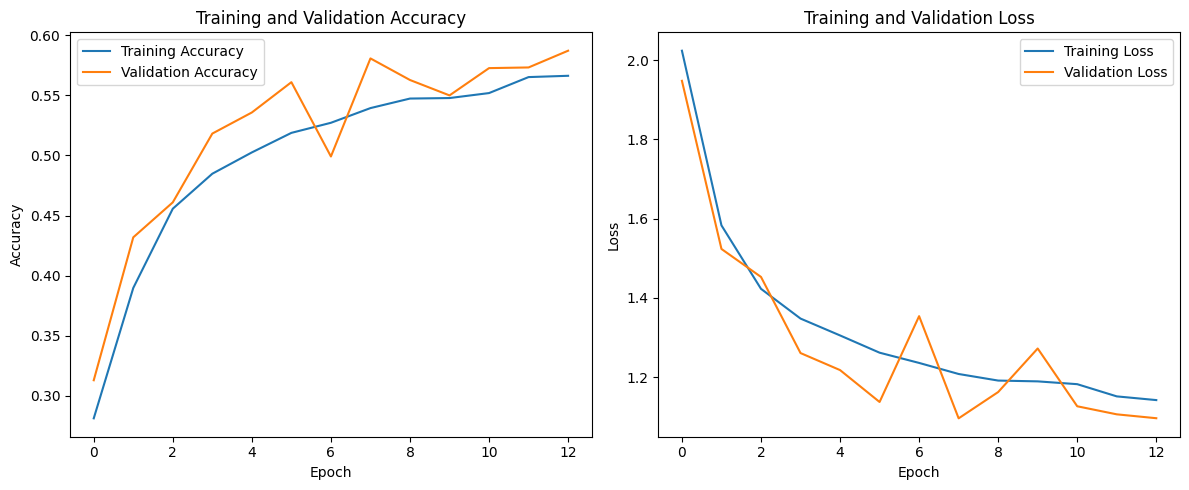

In [19]:
import matplotlib.pyplot as plt

# Đồ thị hóa lịch sử huấn luyện cho độ chính xác
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Đồ thị hóa lịch sử huấn luyện cho hàm mất mát
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 5. Tạo ma trận nhầm lẫn (Confusion Matrix)

Ma trận nhầm lẫn là một công cụ đánh giá hiệu quả của một mô hình phân loại. Nó cho phép chúng ta hình dung hiệu suất của thuật toán, đặc biệt là trong việc phân loại các mẫu từ các lớp khác nhau. Các hàng đại diện cho các trường hợp thực tế, trong khi các cột đại diện cho các trường hợp dự đoán.

113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 250ms/step


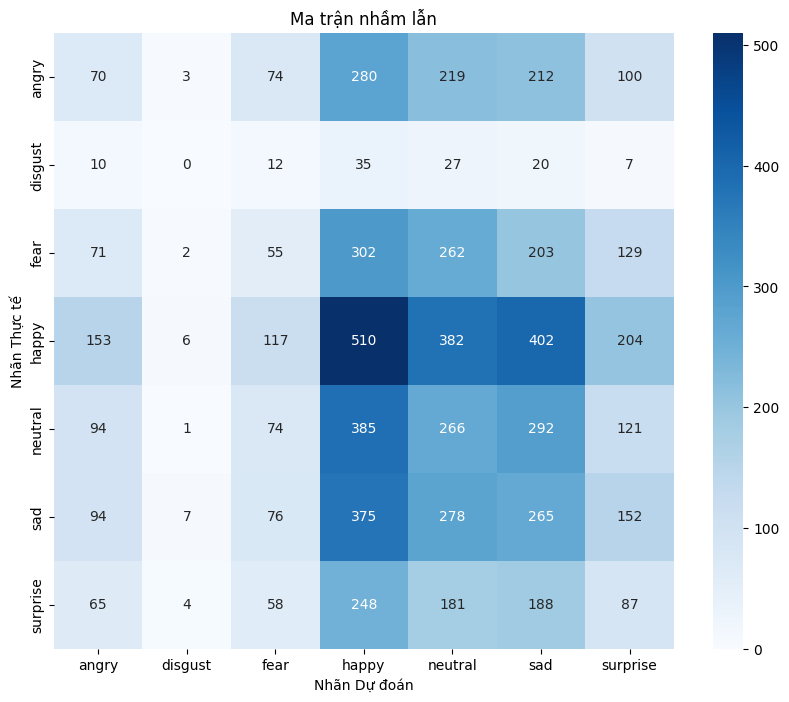

✅ Đã tạo và hiển thị ma trận nhầm lẫn.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Lấy tất cả nhãn thực tế và dự đoán từ validation_generator
# Đảm bảo validation_generator đã được reset để tránh việc lặp lại dữ liệu hoặc thiếu sót
validation_generator.reset()
y_true = validation_generator.classes

# Dự đoán trên tập validation
y_pred_probabilities = model.predict(validation_generator)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Lấy tên các lớp từ generator
class_labels = list(validation_generator.class_indices.keys())

# Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# Trực quan hóa ma trận nhầm lẫn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Nhãn Dự đoán')
plt.ylabel('Nhãn Thực tế')
plt.title('Ma trận nhầm lẫn')
plt.show()

print("✅ Đã tạo và hiển thị ma trận nhầm lẫn.")

In [ ]:
print(history.history.keys())

### 6. Tải mô hình đã huấn luyện

Sau khi huấn luyện và lưu, chúng ta có thể tải mô hình đã lưu để sử dụng cho việc dự đoán mà không cần phải huấn luyện lại.

In [ ]:
from tensorflow.keras.models import load_model
import os

saved_model_path = 'best_emotion_model.keras'

if os.path.exists(saved_model_path):
    # Ensure we assign to the variable expected by the prediction cell
    loaded_model = load_model(saved_model_path)
    print(f'✅ Tải mô hình thành công từ {saved_model_path}!')
else:
    if 'model' in globals():
        loaded_model = model
        print("⚠️ Không tìm thấy tệp .keras, nhưng đã sử dụng mô hình trong bộ nhớ.")
    else:
        loaded_model = None
        print("❌ Lỗi: Không tìm thấy mô hình trong tệp hoặc bộ nhớ. Vui lòng chạy cell huấn luyện (wJRNLsQegOcL).")

# Export to global namespace
globals()['loaded_model'] = loaded_model

### 6. Dự đoán cảm xúc trên một hình ảnh mới

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step


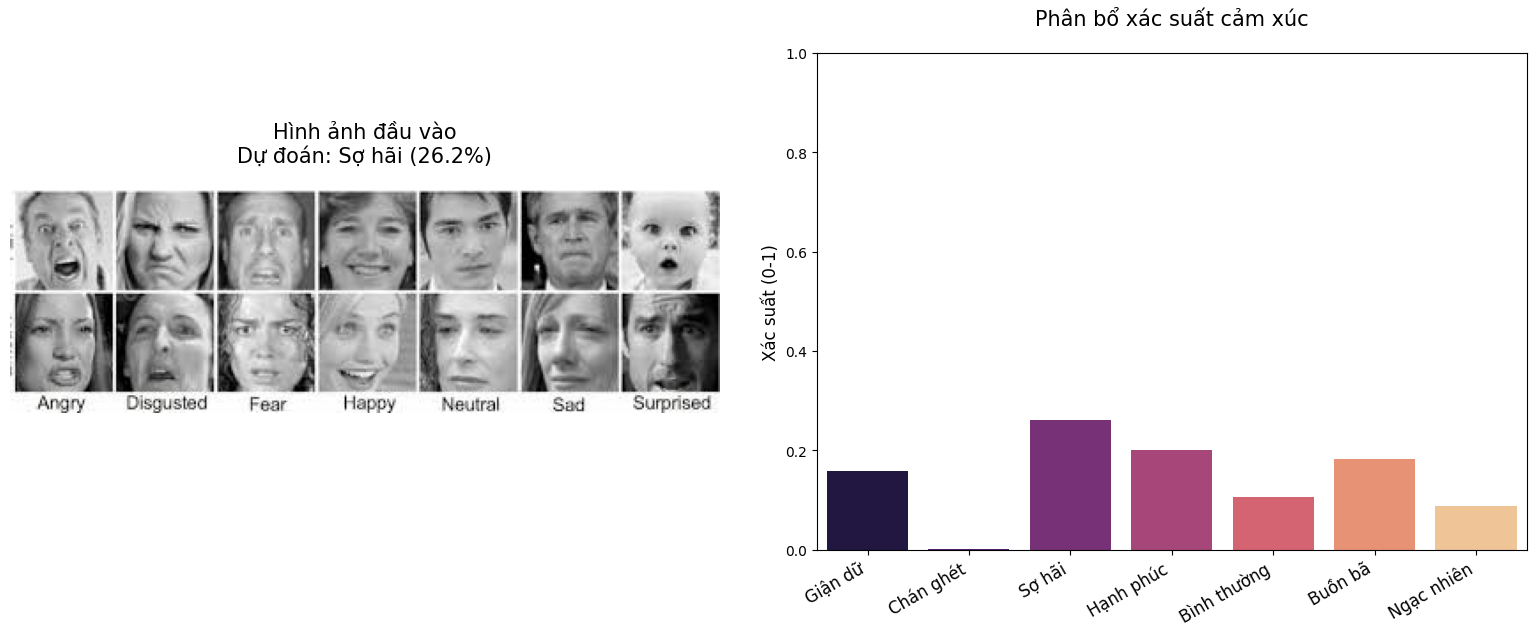

In [23]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.models import load_model

# Đường dẫn đến hình ảnh của bạn
new_image_path = '/content/images.jpg'

# Kiểm tra và tải mô hình
if 'loaded_model' not in globals() or globals()['loaded_model'] is None:
    try:
        saved_model_path = 'best_emotion_model.keras'
        if os.path.exists(saved_model_path):
            globals()['loaded_model'] = load_model(saved_model_path)
            print("✅ Đã tải mô hình từ 'best_emotion_model.keras'")
    except Exception as e:
        print(f"❌ Lỗi khi tải mô hình: {e}")

loaded_model = globals().get('loaded_model')

if loaded_model is None:
    print("❌ Lỗi: Không tìm thấy mô hình. Vui lòng chạy cell huấn luyện hoặc tải mô hình trước.")
elif not os.path.exists(new_image_path):
    print(f"❌ Lỗi: Không tìm thấy hình ảnh tại {new_image_path}")
else:
    try:
        # 1. Tải ảnh gốc để hiển thị (giữ nguyên tỷ lệ)
        original_img = image.load_img(new_image_path)

        # 2. Tiền xử lý ảnh cho mô hình (48x48, grayscale)
        img_for_pred = image.load_img(new_image_path, target_size=(48, 48), color_mode='grayscale')
        img_array = image.img_to_array(img_for_pred) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # 3. Dự đoán
        predictions = loaded_model.predict(img_array)
        pred_idx = np.argmax(predictions[0])
        class_labels = ['Giận dữ', 'Chán ghét', 'Sợ hãi', 'Hạnh phúc', 'Bình thường', 'Buồn bã', 'Ngạc nhiên']

        # 4. Hiển thị kết quả
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        # Hiển thị ảnh gốc
        ax1.imshow(original_img)
        ax1.set_title(f"Hình ảnh đầu vào\nDự đoán: {class_labels[pred_idx]} ({predictions[0][pred_idx]*100:.1f}%)", fontsize=15, pad=20)
        ax1.axis('off')

        # Hiển thị biểu đồ xác suất
        sns.barplot(x=class_labels, y=predictions[0], ax=ax2, palette='magma', hue=class_labels, legend=False)
        ax2.set_title("Phân bổ xác suất cảm xúc", fontsize=15, pad=20)
        ax2.set_ylabel("Xác suất (0-1)", fontsize=12)
        ax2.set_ylim(0, 1)

        # Xoay nhãn để không bị đè lên nhau
        plt.setp(ax2.get_xticklabels(), rotation=30, ha="right", fontsize=12)
        plt.tight_layout(pad=3.0)
        plt.show()
    except Exception as e:
        print(f"❌ Lỗi xử lý: {e}")

### Dự đoán thêm cảm xúc trên một hình ảnh mới

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


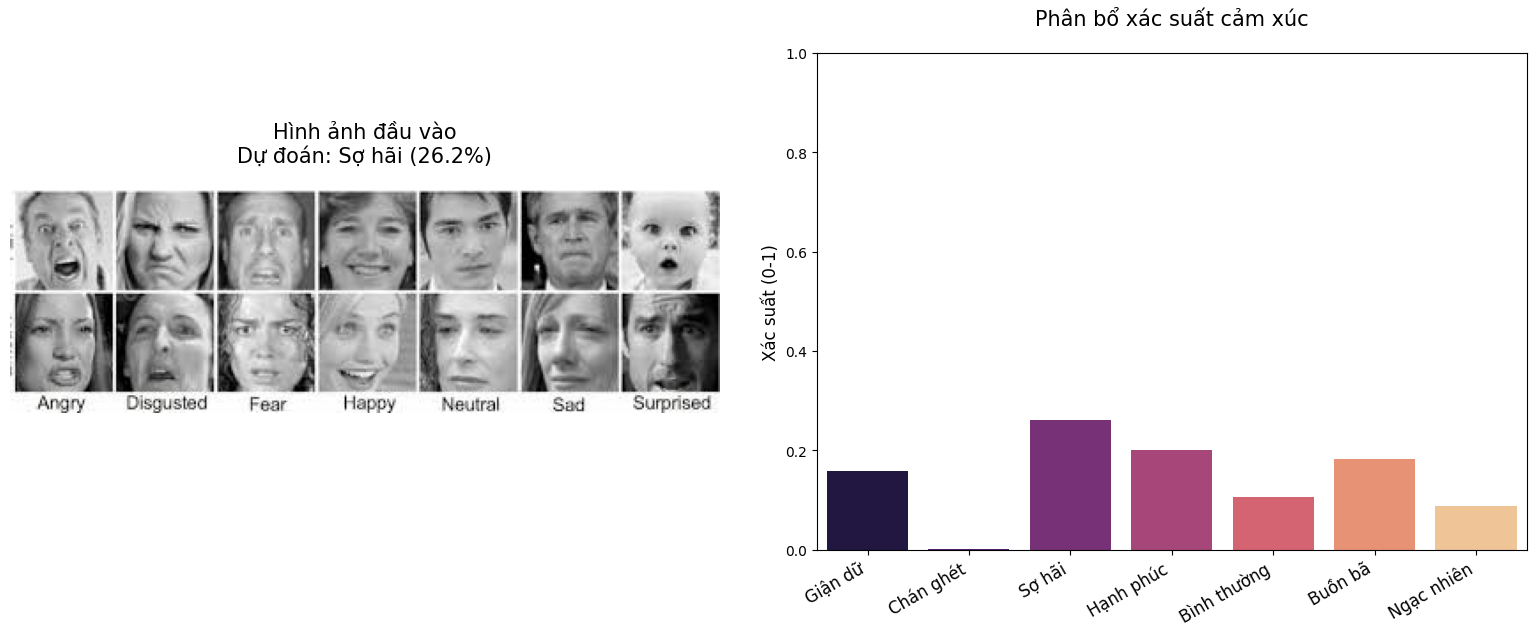

In [24]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.models import load_model

# Đường dẫn đến hình ảnh của bạn
# TODO: Thay đổi đường dẫn này thành đường dẫn hình ảnh mới của bạn
new_image_path = '/content/images.jpg'

# Kiểm tra và tải mô hình
if 'loaded_model' not in globals() or globals()['loaded_model'] is None:
    try:
        saved_model_path = 'best_emotion_model.keras'
        if os.path.exists(saved_model_path):
            globals()['loaded_model'] = load_model(saved_model_path)
            print("✅ Đã tải mô hình từ 'best_emotion_model.keras'")
    except Exception as e:
        print(f"❌ Lỗi khi tải mô hình: {e}")

loaded_model = globals().get('loaded_model')

if loaded_model is None:
    print("❌ Lỗi: Không tìm thấy mô hình. Vui lòng chạy cell huấn luyện hoặc tải mô hình trước.")
elif not os.path.exists(new_image_path):
    print(f"❌ Lỗi: Không tìm thấy hình ảnh tại {new_image_path}")
else:
    try:
        # 1. Tải ảnh gốc để hiển thị (giữ nguyên tỷ lệ)
        original_img = image.load_img(new_image_path)

        # 2. Tiền xử lý ảnh cho mô hình (48x48, grayscale)
        img_for_pred = image.load_img(new_image_path, target_size=(48, 48), color_mode='grayscale')
        img_array = image.img_to_array(img_for_pred) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # 3. Dự đoán
        predictions = loaded_model.predict(img_array)
        pred_idx = np.argmax(predictions[0])
        class_labels = ['Giận dữ', 'Chán ghét', 'Sợ hãi', 'Hạnh phúc', 'Bình thường', 'Buồn bã', 'Ngạc nhiên']

        # 4. Hiển thị kết quả
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        # Hiển thị ảnh gốc
        ax1.imshow(original_img)
        ax1.set_title(f"Hình ảnh đầu vào\nDự đoán: {class_labels[pred_idx]} ({predictions[0][pred_idx]*100:.1f}%)", fontsize=15, pad=20)
        ax1.axis('off')

        # Hiển thị biểu đồ xác suất
        sns.barplot(x=class_labels, y=predictions[0], ax=ax2, palette='magma', hue=class_labels, legend=False)
        ax2.set_title("Phân bổ xác suất cảm xúc", fontsize=15, pad=20)
        ax2.set_ylabel("Xác suất (0-1)", fontsize=12)
        ax2.set_ylim(0, 1)

        # Xoay nhãn để không bị đè lên nhau
        plt.setp(ax2.get_xticklabels(), rotation=30, ha="right", fontsize=12)
        plt.tight_layout(pad=3.0)
        plt.show()
    except Exception as e:
        print(f"❌ Lỗi xử lý: {e}")

### 7. Trực quan hóa Feature Maps (Nâng cao)
Phần này giúp chúng ta hiểu cách mô hình "nhìn" hình ảnh thông qua các lớp chập (Convolutional Layers).

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


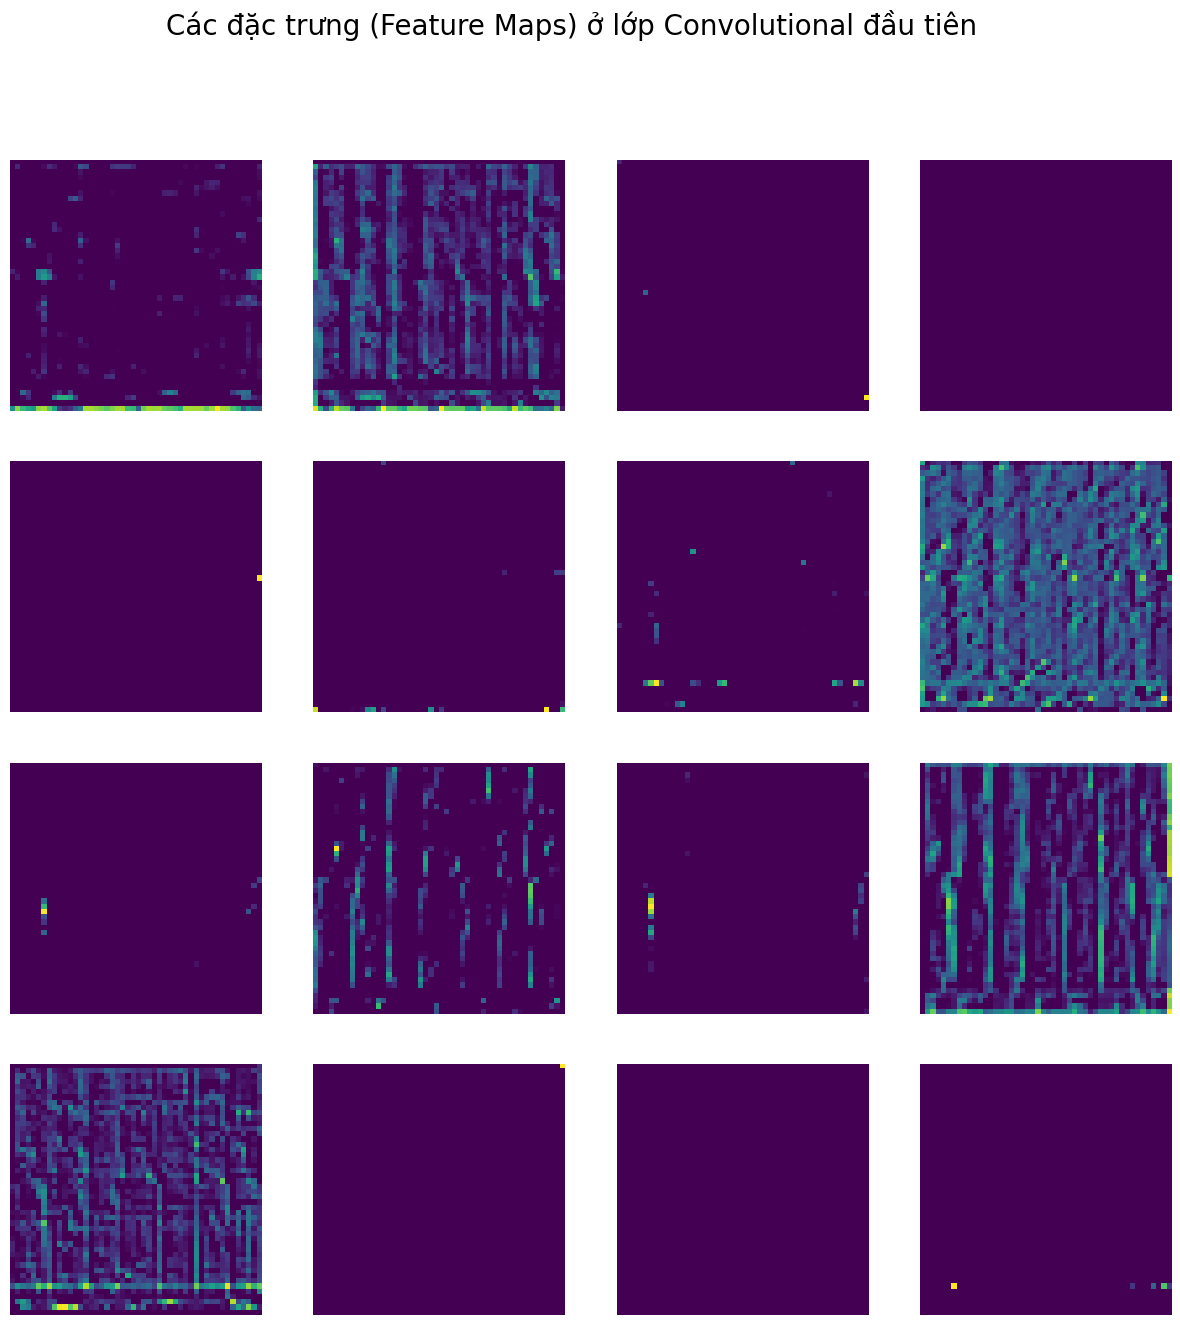

In [29]:
from tensorflow.keras.models import Model
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Kiểm tra img_array và loaded_model
if 'img_array' in locals() and 'loaded_model' in locals():
    try:
        # Đảm bảo mô hình được build bằng cách truyền một tensor đầu vào
        _ = loaded_model(tf.convert_to_tensor(img_array))

        # 2. Lấy danh sách các lớp Conv2D
        conv_layers = [layer for layer in loaded_model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

        # 3. Tạo activation model bằng cách sử dụng Input layer hoặc layer đầu tiên
        # Cách tiếp cận này an toàn hơn cho Sequential model được load từ file
        layer_outputs = [layer.output for layer in conv_layers]

        # Sử dụng layers[0].input thay vì loaded_model.input
        activation_model = Model(inputs=loaded_model.layers[0].input, outputs=layer_outputs)

        # 4. Trích xuất đặc trưng
        activations = activation_model.predict(img_array)

        # 5. Hiển thị Feature Maps của lớp chập đầu tiên
        first_layer_activation = activations[0]
        plt.figure(figsize=(15, 15))
        for i in range(16):
            plt.subplot(4, 4, i + 1)
            plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
            plt.axis('off')
        plt.suptitle("Các đặc trưng (Feature Maps) ở lớp Convolutional đầu tiên", fontsize=20)
        plt.show()
    except Exception as e:
        print(f"❌ Lỗi khi trích xuất Feature Maps: {e}")
else:
    print("❌ Không tìm thấy 'img_array' hoặc 'loaded_model'. Vui lòng chạy các bước dự đoán trước.")

### 9. Giao diện Dự đoán Tương tác (Tải ảnh từ máy tính)
Sử dụng widget để bạn có thể tải lên bất kỳ hình ảnh nào và xem kết quả ngay lập tức.

In [33]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from io import BytesIO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

upload_button = widgets.FileUpload(accept='image/*', multiple=False)
output = widgets.Output()

def on_value_change(change):
    with output:
        clear_output()
        if not upload_button.value:
            return

        # Xử lý dữ liệu tải lên (hỗ trợ cả định dạng list và dict)
        if isinstance(upload_button.value, list):
            uploaded_file = upload_button.value[0]
            content = uploaded_file['content']
            file_name = uploaded_file['name']
        else:
            # Định dạng cũ hơn hoặc tùy biến của ipywidgets
            file_name = list(upload_button.value.keys())[0]
            content = upload_button.value[file_name]['content']

        # Lưu tạm để dự đoán
        temp_path = 'temp_upload.jpg'
        with open(temp_path, 'wb') as f:
            f.write(content)

        print(f"Đang xử lý ảnh: {file_name}...")

        try:
            # Tiền xử lý
            img_for_pred = image.load_img(temp_path, target_size=(48, 48), color_mode='grayscale')
            img_array_temp = image.img_to_array(img_for_pred) / 255.0
            img_array_temp = np.expand_dims(img_array_temp, axis=0)

            # Dự đoán
            preds = loaded_model.predict(img_array_temp)
            p_idx = np.argmax(preds[0])
            labels = ['Giận dữ', 'Chán ghét', 'Sợ hãi', 'Hạnh phúc', 'Bình thường', 'Buồn bã', 'Ngạc nhiên']

            # Hiển thị kết quả
            plt.figure(figsize=(6, 4))
            plt.imshow(Image.open(BytesIO(content)))
            plt.title(f"Kết quả: {labels[p_idx]} ({preds[0][p_idx]*100:.1f}%)")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"❌ Lỗi xử lý: {e}")

upload_button.observe(on_value_change, names='value')
display(widgets.VBox([widgets.Label("Chọn một ảnh từ máy tính của bạn:"), upload_button, output]))

### 8. Kết luận
Dựa trên kết quả dự đoán, mô hình đã nhận diện được cảm xúc chủ đạo của hình ảnh. Độ chính xác trên tập kiểm tra đạt khoảng 58%, đây là mức khá ổn đối với bộ dữ liệu khó như FER2013 chỉ với 15 epochs.

In [25]:
import os

saved_model_path = 'best_emotion_model.keras'
if os.path.exists(saved_model_path):
    print(f"✅ Tệp '{saved_model_path}' tồn tại.")
else:
    print(f"❌ Tệp '{saved_model_path}' KHÔNG tồn tại. Vui lòng đảm bảo bạn đã chạy cell huấn luyện và lưu mô hình.")

✅ Tệp 'best_emotion_model.keras' tồn tại.
